In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
plt.rcParams.update({
    "text.usetex": False,               # disable if no full TeX install
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.dpi": 200,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_context("paper", font_scale=1.2)
sns.set_style("whitegrid")

In [12]:
# Load Sharon's annotated data
results_df = pd.read_csv("../results/model_results_all_chapters_1649.csv")
sharon_data = pd.read_excel("../data/manual/pride_and_prejudice.xlsx", sheet_name="ALL INSTANCES")

In [24]:
results_df.head(50)

,chapter,method,character,tag,count
0,1,whole,Captain Carter,N,0
1,1,whole,Captain Carter,A,0
2,1,whole,Captain Carter,C,0
3,1,whole,Captain Carter,I,0
4,1,whole,Captain Carter,DN,0
5,1,whole,Captain Carter,DC,0
6,1,whole,Charlotte Lucas,N,0
7,1,whole,Charlotte Lucas,A,0
8,1,whole,Charlotte Lucas,C,0
9,1,whole,Charlotte Lucas,I,0


In [16]:
sharon_data = sharon_data.drop(columns=["Volume", "B", "FID", "Graph Chapter"])
sharon_data.head()

KeyError: "['Volume', 'B', 'FID', 'Graph Chapter'] not found in axis"

In [19]:
# Prepare Sharon's data (true counts)
sharon_long = (
    sharon_data.melt(
        id_vars=["Chapter", "Character"],
        value_vars=["N","A","C","I","DN","DC"],
        var_name="tag",
        value_name="true_count"
    )
    .rename(columns={"Character":"character","Chapter":"chapter"})
)
sharon_long.head(15)

,chapter,character,tag,true_count
0,7,Captain Carter,N,2.0
1,9,Captain Carter,N,1.0
2,5,Charlotte Lucas,N,3.0
3,6,Charlotte Lucas,N,7.0
4,9,Charlotte Lucas,N,3.0
5,13,Charlotte Lucas,N,1.0
6,18,Charlotte Lucas,N,5.0
7,20,Charlotte Lucas,N,6.0
8,21,Charlotte Lucas,N,1.0
9,22,Charlotte Lucas,N,17.0


In [27]:
# Aggregate model outputs
agg_model = (
    results_df.groupby(["method", "chapter", "character", "tag"])["count"]
    .sum()
    .reset_index()
)

# Merge model predictions with Sharon's ground truth (align by chapter)
merged = agg_model.merge(sharon_long, on=["chapter", "character", "tag"], how="outer")
merged["count"] = merged["count"].fillna(0)
merged["true_count"] = merged["true_count"].fillna(0)
merged["true_count"] = merged["true_count"].astype(int)

mask_nonzero = (
    merged.groupby(["chapter", "character"])[["count", "true_count"]]
    .transform(lambda x: (x != 0).any())
).any(axis=1)

merged_filtered = merged[mask_nonzero].copy().reset_index(drop=True)
merged_filtered.head(20)


,method,chapter,character,tag,count,true_count
0,chunked,1,Charlotte Lucas,A,0,0
1,separate,1,Charlotte Lucas,A,0,0
2,whole,1,Charlotte Lucas,A,0,0
3,chunked,1,Charlotte Lucas,C,0,0
4,separate,1,Charlotte Lucas,C,0,0
5,whole,1,Charlotte Lucas,C,0,0
6,chunked,1,Charlotte Lucas,DC,0,9
7,separate,1,Charlotte Lucas,DC,0,9
8,whole,1,Charlotte Lucas,DC,0,9
9,chunked,1,Charlotte Lucas,DN,0,0


In [28]:
# --- Basic error metrics per method ---
stats = (
    merged_filtered  # your final merged dataframe
    .assign(abs_error=lambda d: (d["count"] - d["true_count"]).abs(),
            error=lambda d: d["count"] - d["true_count"])
    .groupby("method")[["count", "true_count", "error", "abs_error"]]
    .agg({
        "count": "sum",
        "true_count": "sum",
        "error": "mean",
        "abs_error": "mean"
    })
)

# --- Add accuracy & recall-style metrics ---
stats["MAE"] = stats["abs_error"]
stats["MRE"] = stats["abs_error"] / (stats["true_count"].replace(0, np.nan))
stats["Total Accuracy"] = (
    1 - (stats["abs_error"].sum() / stats["true_count"].sum())
)
print(stats.round(3))

          count  true_count  error  abs_error    MAE  MRE  Total Accuracy
method                                                                   
chunked   17653       12576  0.658      2.924  2.924  0.0             1.0
separate  16548       12576  0.515      2.812  2.812  0.0             1.0
whole      7971       12576 -0.597      2.070  2.070  0.0             1.0


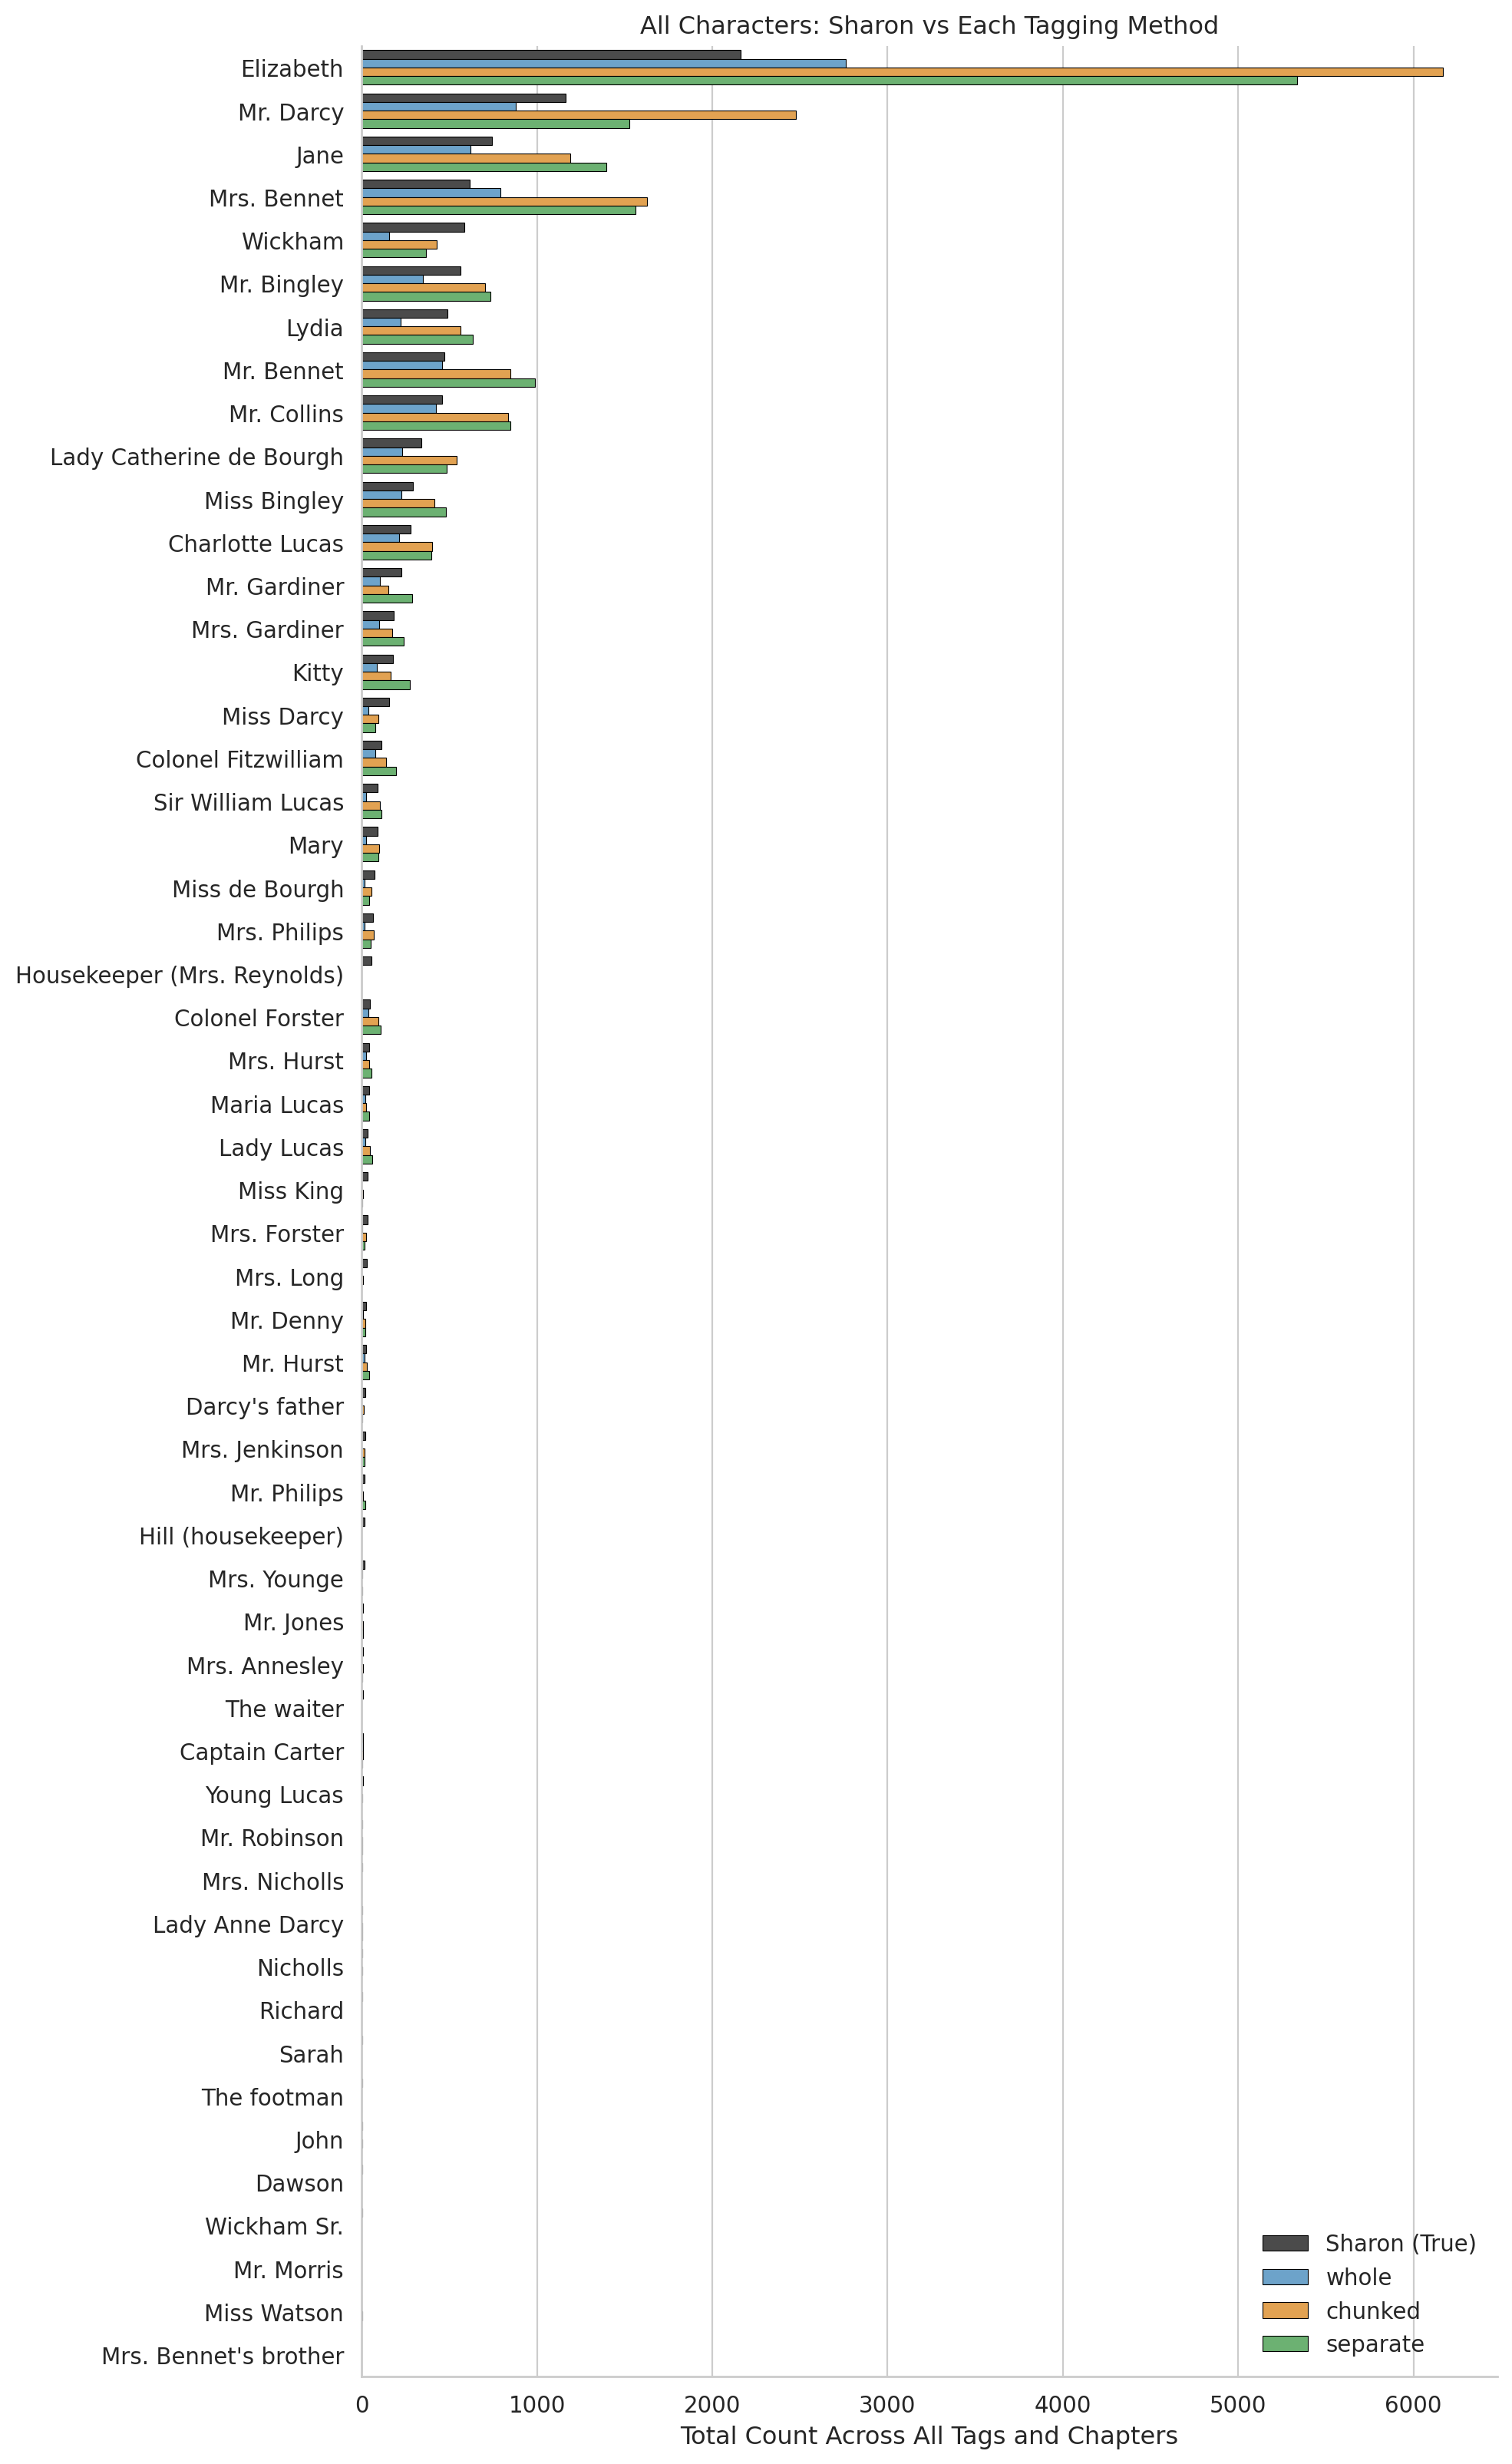

In [36]:
# --- 1) Prepare combined dataframe ---
model_totals = (
    merged_filtered
    .groupby(["character", "method"], as_index=False)["count"]
    .sum()
)

# Deduplicate Sharon (remove triple count)
sharon_totals = (
    merged_filtered
    .groupby(["chapter", "character", "tag"], as_index=False)["true_count"]
    .max()
    .groupby(["character"], as_index=False)["true_count"]
    .sum()
)
sharon_totals["method"] = "Sharon (True)"
sharon_totals = sharon_totals.rename(columns={"true_count": "count"})

# Combine into one DataFrame
plot_df = pd.concat([sharon_totals, model_totals], ignore_index=True)

# --- 2) Sort characters by Sharon total descending ---
char_order = (
    sharon_totals.sort_values("count", ascending=False)["character"]
    .tolist()
)
plot_df["character"] = pd.Categorical(plot_df["character"], categories=char_order, ordered=True)

# --- 3) Define method order so Sharon appears first ---
method_order = ["Sharon (True)", "whole", "chunked", "separate"]

# --- 4) Color palette ---
palette = {
    "Sharon (True)": "#4B4B4B",
    "whole": "#5DA5DA", 
    "chunked": "#FAA43A", 
    "separate": "#60BD68",
}

# --- 5) Plot ---
plt.figure(figsize=(10, max(6, len(char_order) * 0.3)))

sns.barplot(
    data=plot_df,
    y="character", x="count", hue="method",
    order=char_order,
    hue_order=method_order,
    palette=palette,
    edgecolor="black",
    linewidth=0.4,
    dodge=True,
    errorbar=None
)

plt.title("All Characters: Sharon vs Each Tagging Method")
plt.xlabel("Total Count Across All Tags and Chapters")
plt.ylabel("")
plt.legend(frameon=False, loc="lower right", title="")
sns.despine()
plt.tight_layout()
plt.show()

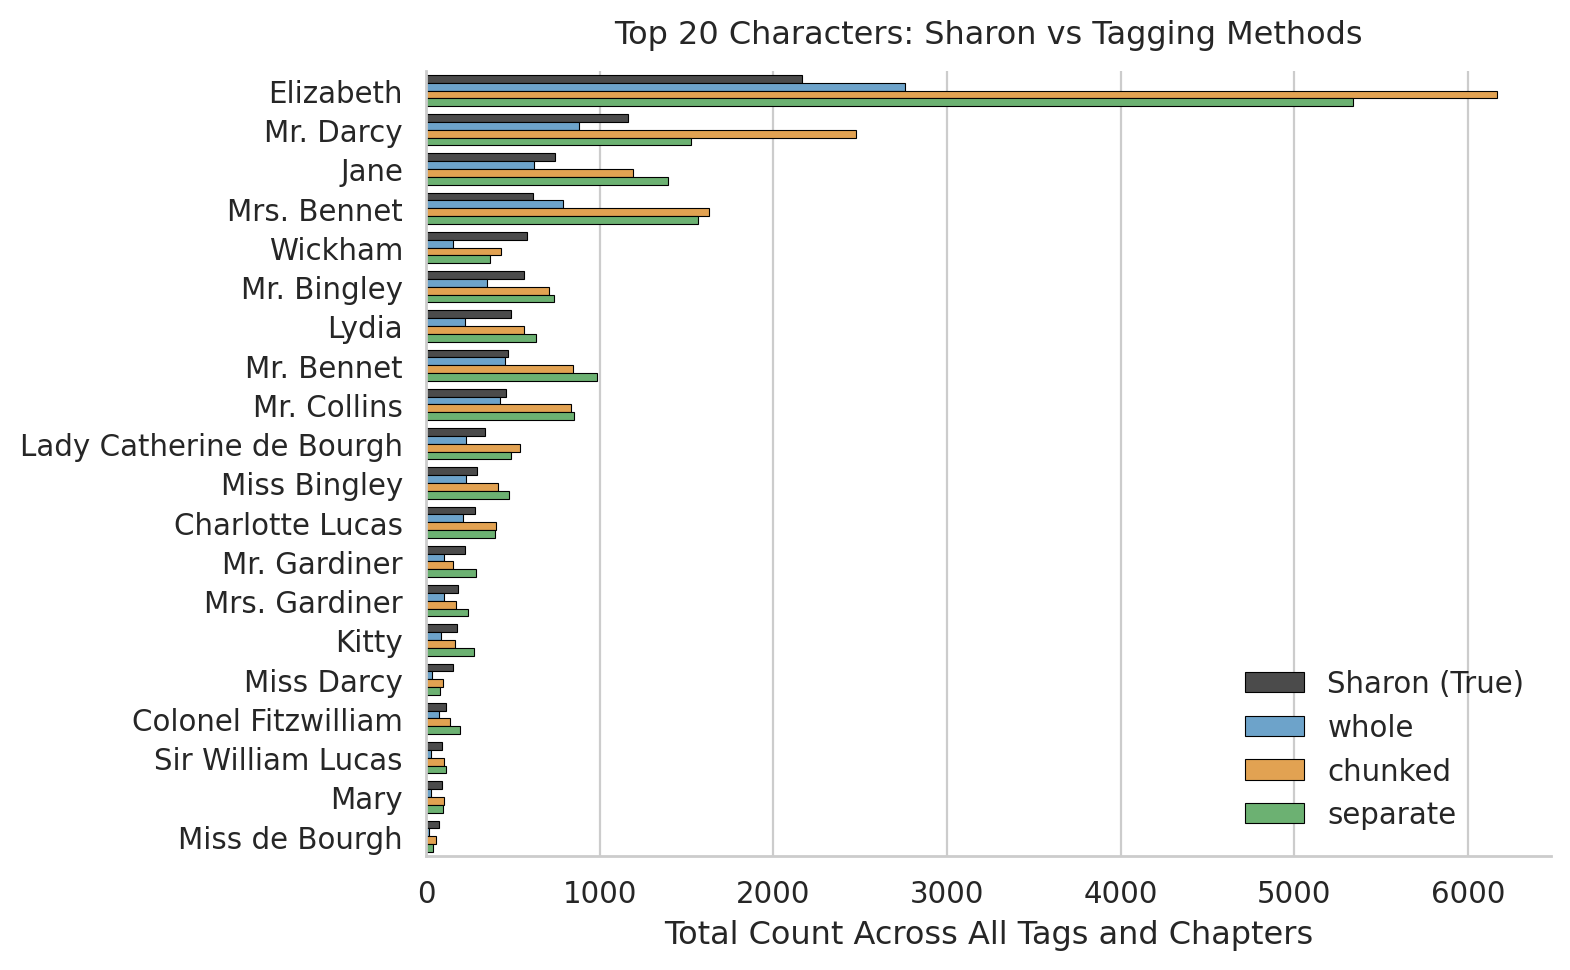

In [38]:
# Aggregate model and true counts
model_totals = (
    merged_filtered
    .groupby(["character", "method"], as_index=False)["count"]
    .sum()
)

# Deduplicate Sharon across methods (max per tag per chapter then sum)
sharon_totals = (
    merged_filtered
    .groupby(["chapter", "character", "tag"], as_index=False)["true_count"]
    .max()
    .groupby(["character"], as_index=False)["true_count"]
    .sum()
)
sharon_totals["method"] = "Sharon (True)"
sharon_totals = sharon_totals.rename(columns={"true_count": "count"})

# Combine all
plot_df = pd.concat([sharon_totals, model_totals], ignore_index=True)

# determine top 20 characters by Sharon total 
top_chars = (
    sharon_totals.sort_values("count", ascending=False)
    .head(20)["character"].tolist()
)
plot_df = plot_df[plot_df["character"].isin(top_chars)]

# Ensure correct order
plot_df["character"] = pd.Categorical(
    plot_df["character"], categories=top_chars, ordered=True
)

# Define colors and order
method_order = ["Sharon (True)", "whole", "chunked", "separate"]


# Plot
plt.figure(figsize=(8, 5))

sns.barplot(
    data=plot_df,
    y="character", x="count", hue="method",
    hue_order=method_order, order=top_chars,
    palette=palette,
    edgecolor="black",
    linewidth=0.4,
    dodge=True,
    errorbar=None
)

plt.title("Top 20 Characters: Sharon vs Tagging Methods", pad=10)
plt.xlabel("Total Count Across All Tags and Chapters")
plt.ylabel("")
plt.legend(frameon=False, loc="lower right", title="")
sns.despine()
plt.tight_layout()
plt.show()

In [51]:
# Basic per-method metrics 
mf = merged_filtered.assign(
    error=lambda d: d["count"] - d["true_count"],
    abs_error=lambda d: (d["count"] - d["true_count"]).abs()
)

stats = (
    mf.groupby("method", as_index=False)
      .agg(
          total_pred=("count", "sum"),
          total_true=("true_count", "sum"),
          mae=("abs_error", "mean"),   # mean absolute error per row
          rmse=("error", lambda x: np.sqrt(np.mean(np.square(x)))),  # root mean square error
          corr=("count", lambda x: np.corrcoef(x, mf.loc[x.index, "true_count"])[0, 1] 
                if len(x) > 1 else np.nan)
      )
)

# Bias direction
stats["bias"] = (stats["total_pred"] - stats["total_true"]) / stats["total_true"].replace(0, np.nan)

# accuracy summary
stats["total_abs_error"] = abs(stats["total_pred"] - stats["total_true"])
stats["accuracy"] = 1 - (stats["total_abs_error"] / stats["total_true"].replace(0, np.nan))

# Display
print(stats[["method", "total_pred", "total_true", "bias", "mae", "rmse", "corr", "accuracy"]].round(3))

     method  total_pred  total_true   bias    mae   rmse   corr  accuracy
0   chunked       17653       12576  0.404  2.924  6.371  0.162     0.596
1  separate       16548       12576  0.316  2.812  5.583  0.141     0.684
2     whole        7971       12576 -0.366  2.070  4.783  0.151     0.634


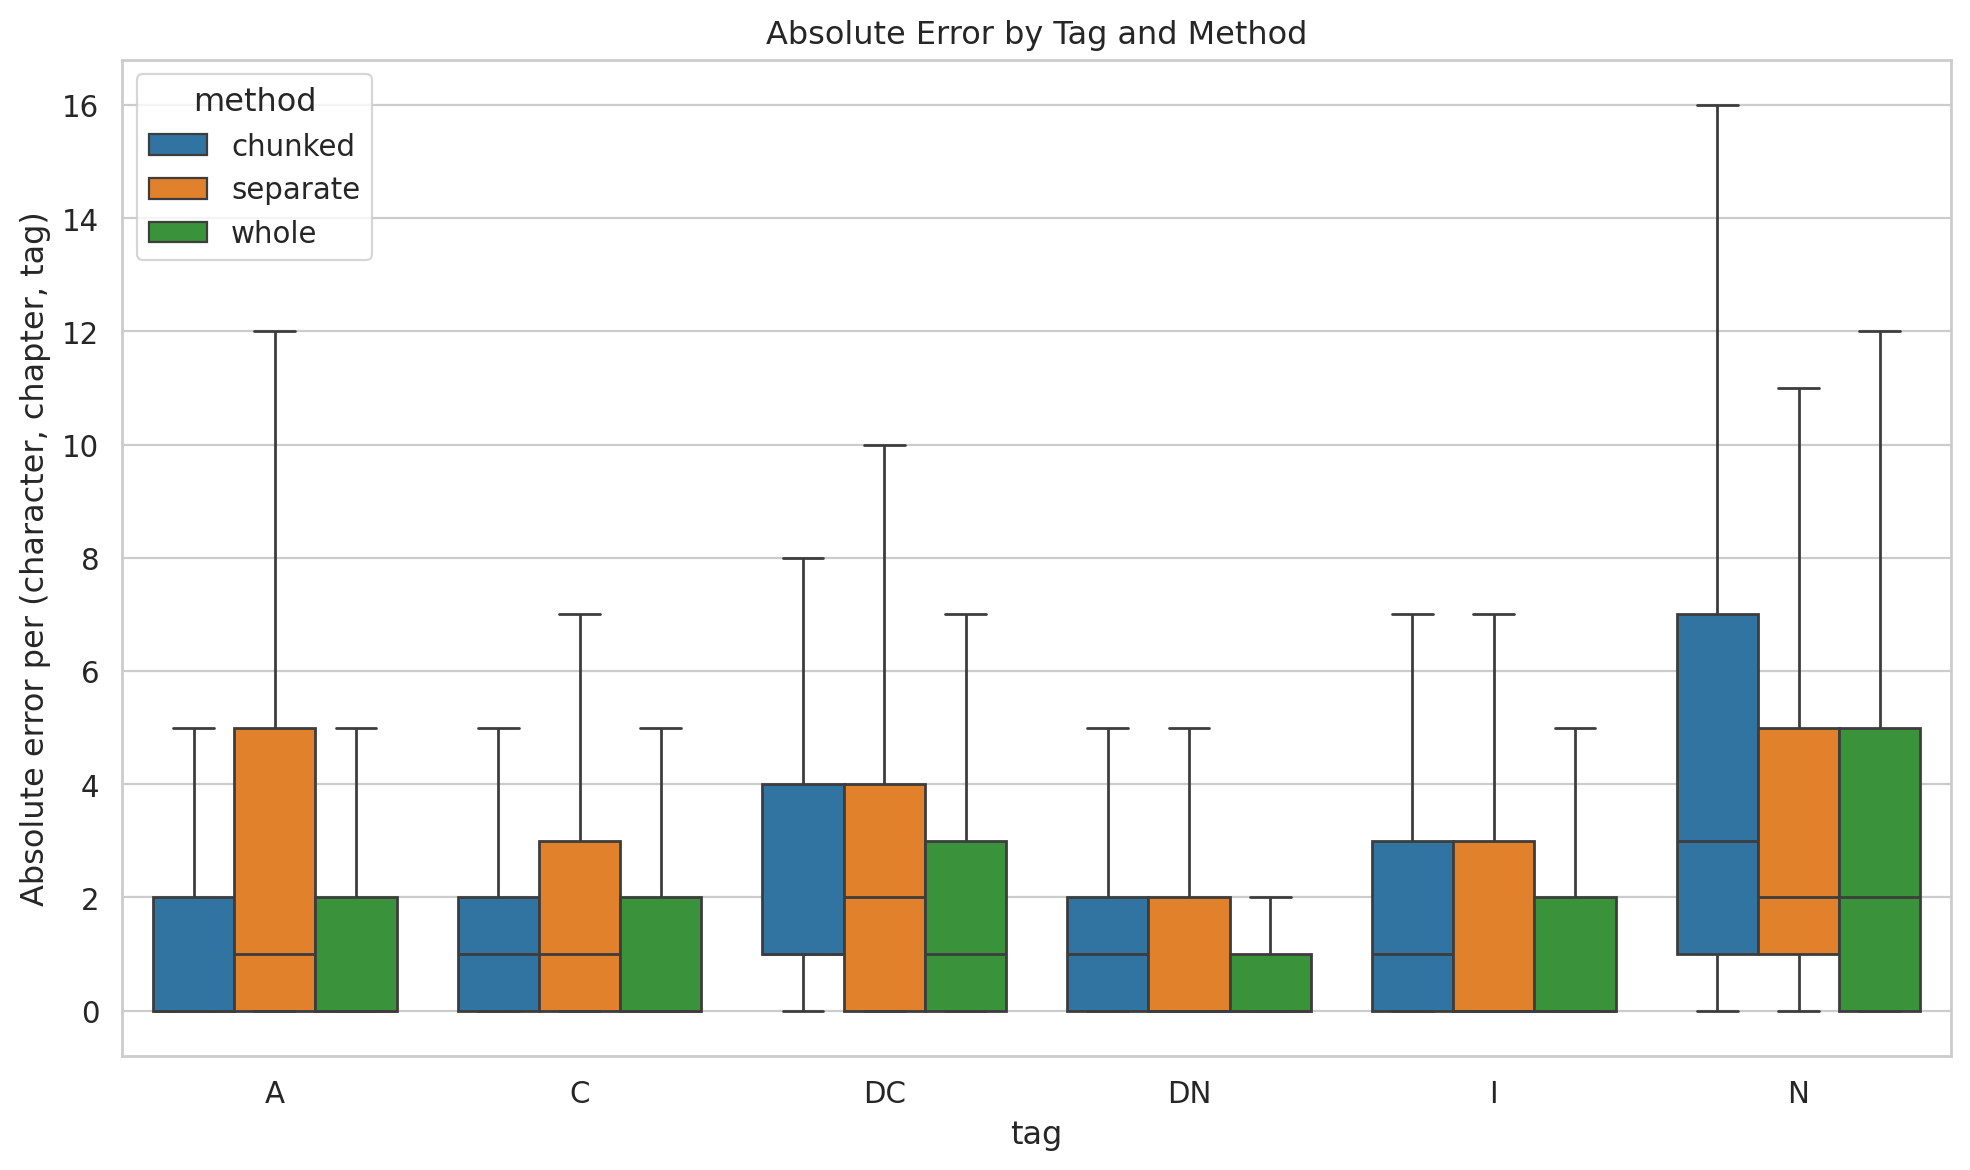

In [40]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=merged_filtered, x="tag", y="abs_error",
            hue="method", showfliers=False)
plt.title("Absolute Error by Tag and Method")
plt.ylabel("Absolute error per (character, chapter, tag)")
plt.tight_layout()
plt.show()

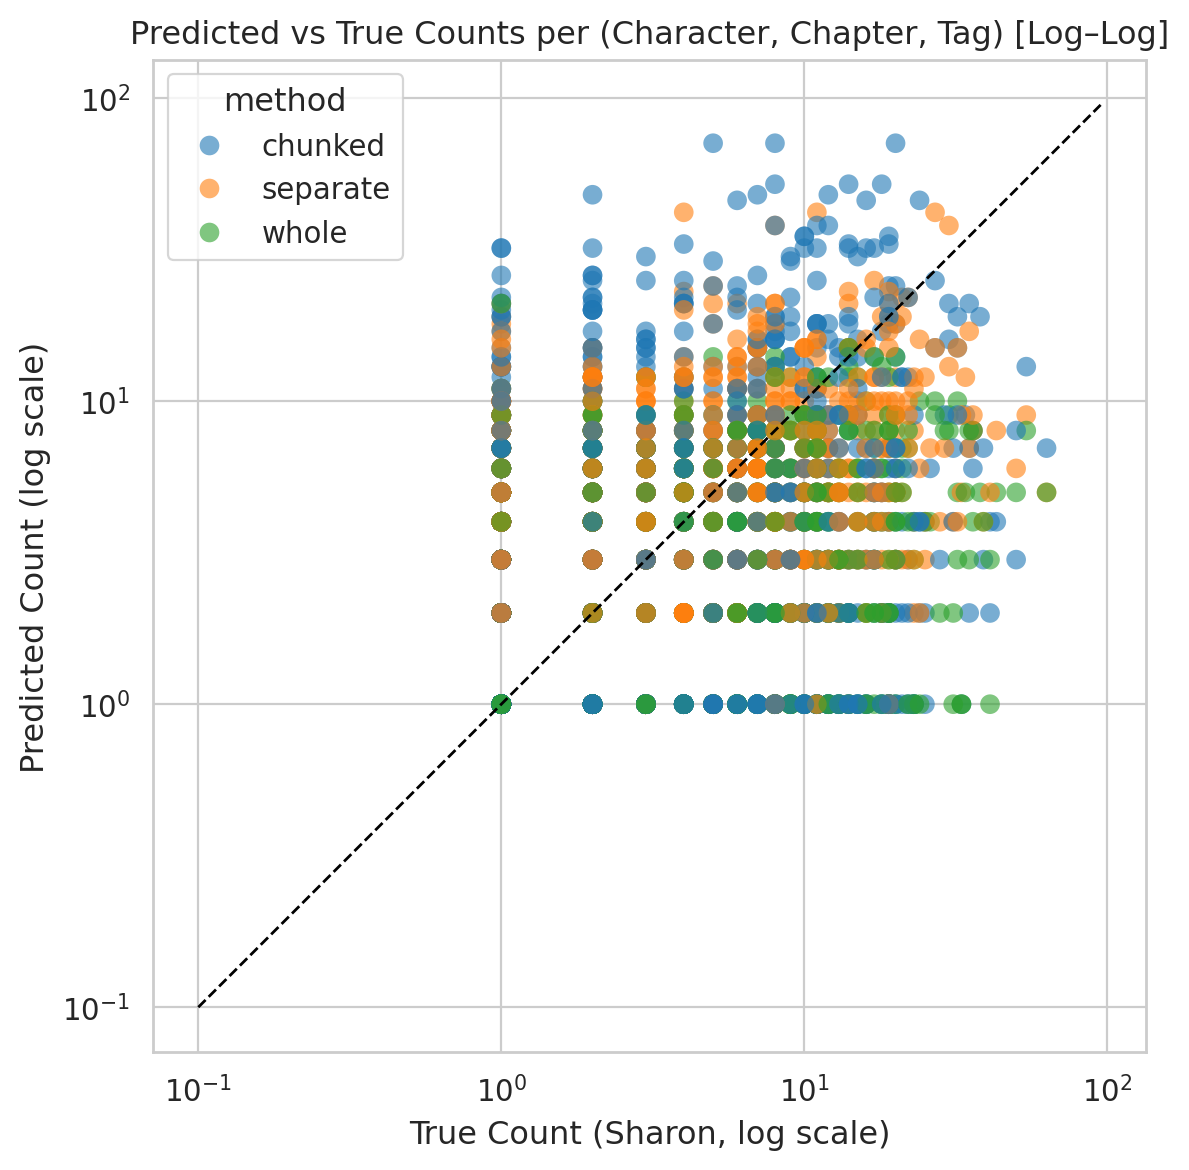

In [44]:
plt.figure(figsize=(8, 6))

# Scatter points
sns.scatterplot(
    data=merged_filtered,
    x="true_count", y="count",
    hue="method", alpha=0.6, s=50, edgecolor="none"
)
# Axes scaling
plt.xscale("log")
plt.yscale("log")

# Diagonal reference line (y = x)
max_val = max(merged_filtered["true_count"].max(), merged_filtered["count"].max())
min_val = 1e-1  # avoid log(0)
plt.plot([min_val, max_val], [min_val, max_val], "k--", lw=1)

# plotting
plt.xlabel("True Count (Sharon, log scale)")
plt.ylabel("Predicted Count (log scale)")
plt.title("Predicted vs True Counts per (Character, Chapter, Tag) [Log–Log]")
plt.gca().set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

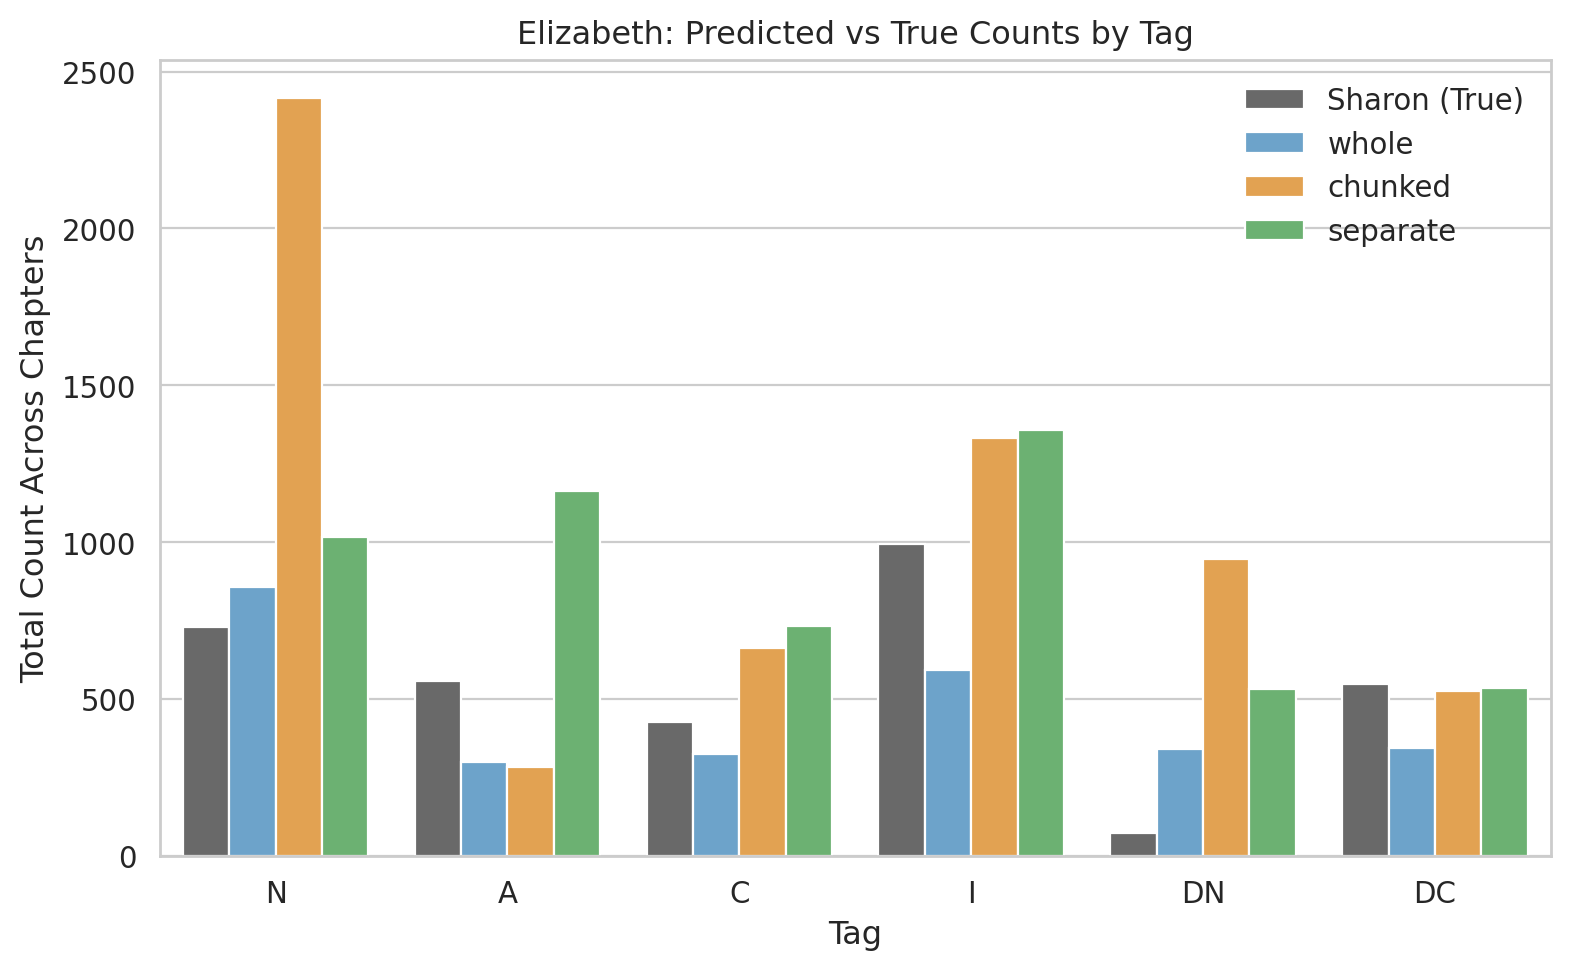

In [49]:
def plot_character_breakdown(char_name):
    """Plot true vs. predicted tag counts for one character, with Sharon's bar first."""

    # --- model predictions (summed across all chapters)
    pred = (
        merged_filtered[merged_filtered["character"].str.contains(char_name, case=False)]
        .groupby(["tag", "method"], as_index=False)["count"].sum()
    )

    # --- Sharon truth (directly from original data)
    true = (
        sharon_long[sharon_long["character"].str.contains(char_name, case=False)]
        .groupby("tag", as_index=False)["true_count"].sum()
    )

    # --- consistent tag order
    tag_order = ["N", "A", "C", "I", "DN", "DC"]
    for df in [pred, true]:
        df["tag"] = pd.Categorical(df["tag"], categories=tag_order, ordered=True)

    # --- merge true + predicted (Sharon first)
    true["method"] = "Sharon (True)"
    true = true.rename(columns={"true_count": "count"})
    plot_df = pd.concat([true, pred], ignore_index=True)

    # --- palette
    palette = {
        "Sharon (True)": "dimgray",
        "whole": "#5DA5DA",
        "chunked": "#FAA43A",
        "separate": "#60BD68"
    }

    # --- plot
    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=plot_df,
        x="tag", y="count", hue="method",
        hue_order=["Sharon (True)", "whole", "chunked", "separate"],
        palette=palette, errorbar=None
    )
    plt.title(f"{char_name}: Predicted vs True Counts by Tag")
    plt.ylabel("Total Count Across Chapters")
    plt.xlabel("Tag")
    plt.legend(title="", frameon=False)
    plt.tight_layout()
    plt.show()

plot_character_breakdown("Elizabeth")